# Air Quality & Health Analytics
### Análise do impacto da qualidade do ar nas internações hospitalares

---
**Estado:** São Paulo  
**Período:** 2022–2023  
**Stack:** Python 3.11 · pandas · scikit-learn · PostgreSQL · Docker

## 1. Contexto do Problema

A qualidade do ar é um dos principais determinantes de saúde pública. Poluentes como PM2.5 e PM10 são partículas finas associadas a doenças respiratórias e cardiovasculares. Condições climáticas (temperatura, umidade, precipitação) influenciam tanto a concentração desses poluentes quanto a vulnerabilidade da população.

**Perguntas que este projeto responde:**
- Existe correlação entre poluição do ar e internações por doenças respiratórias?
- Quais poluentes têm maior associação com internações?
- É possível prever o nível de PM2.5 a partir de variáveis climáticas?
- Quando o risco de internações é elevado?

## 2. Fontes de Dados

| Dataset | Fonte | Formato | Cobertura |
|---|---|---|---|
| Qualidade do ar | OpenAQ API v3 | JSON → CSV | SP, 2022–2023 |
| Dados climáticos | INMET Dados Históricos | ZIP/CSV | SP, 2022–2023 |
| Internações | DATASUS SIH/SUS via PySUS | DBC → CSV | SP, CID J00–J99 |

**Variável-alvo de regressão:** `pollution_pm25` (concentração de PM2.5 em µg/m³)  
**Variável-alvo de classificação:** `high_admissions` (internações acima da mediana diária)

In [16]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from sqlalchemy import text

from src.utils.db import get_engine

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

PLOTS_DIR = Path('../data/processed/analysis/plots')
ANALYSIS_DIR = Path('../data/processed/analysis')

print('Ambiente configurado.')

Ambiente configurado.


## 3. Pipeline de Dados

```
OpenAQ API  ──┐
INMET ZIP   ──┼──► Ingestão ──► Processamento ──► Transformação ──► Integração ──► PostgreSQL
DATASUS FTP ──┘
                                                                          │
                                                               dataset_final.csv
```

**Decisões técnicas:**
- Dados brutos preservados em `/data/raw/` sem modificação (idempotência)
- Limpeza na camada de processamento: nulos removidos, tipos corrigidos, colunas em `snake_case`
- Feature engineering: médias móveis de 7 dias, amplitude térmica, taxa de internações
- Join por `date` após agregar ao nível estadual SP
- Split temporal (não aleatório) para evitar *data leakage* nos modelos

In [17]:
engine = get_engine()

with engine.connect() as conn:
    df = pd.read_sql(text('SELECT * FROM dataset_final'), conn, parse_dates=['date'])

df = df.sort_values('date').reset_index(drop=True)
print(f'Shape: {df.shape}')
print(f'Período: {df["date"].min().date()} → {df["date"].max().date()}')
df.head()

Shape: (730, 31)
Período: 2022-01-01 → 2023-12-31


,date,pollution_co,pollution_no2,pollution_o3,pollution_pm10,pollution_pm25,pollution_so2,pollution_co_ma7d,pollution_no2_ma7d,pollution_o3_ma7d,...,pressure_mb_mean,temp_variation_c,temperature_c_mean_ma7d,humidity_pct_mean_ma7d,precipitation_mm_sum_ma7d,admissions,deaths,avg_stay_days,admissions_ma7d,year_month
0,2022-01-01,0.350833,28.895000,43.607500,21.401667,12.692500,6.096667,0.350833,28.895000,43.607500,...,940.28125,10.10,21.193750,71.000000,2.150000,47,0,3.063830,47.000000,2022-01
1,2022-01-02,0.382500,34.844167,42.702500,19.523333,10.470000,6.330833,0.366667,31.869583,43.155000,...,938.48125,11.05,21.321875,71.065625,2.125000,39,2,4.282051,43.000000,2022-01
2,2022-01-03,0.389167,35.830833,44.062500,18.538333,16.969167,8.679167,0.374167,33.190000,43.457500,...,940.30625,6.45,21.252083,71.854167,2.166667,47,0,5.255319,44.333333,2022-01
3,2022-01-04,0.457500,31.076667,39.218333,17.192500,18.141667,4.997500,0.395000,32.661667,42.397708,...,941.06250,8.25,21.479688,71.085938,2.387500,32,1,5.156250,41.250000,2022-01
4,2022-01-05,0.521667,36.015000,44.447500,12.290833,11.449167,6.203333,0.420333,33.332333,42.807667,...,938.55625,10.10,21.383750,71.381250,2.450000,22,1,5.000000,37.400000,2022-01


## 4. Processo de Limpeza

Resumo das operações aplicadas em cada camada:

In [18]:
print('=== Tipos de dados ===')
print(df.dtypes.to_string())

print('\n=== Valores ausentes (%) ===')
missing = (df.isnull().sum() / len(df) * 100).round(2)
print(missing[missing > 0].to_string() if missing[missing > 0].any() else 'Nenhum valor ausente.')

=== Tipos de dados ===
date                         datetime64[ns]
pollution_co                        float64
pollution_no2                       float64
pollution_o3                        float64
pollution_pm10                      float64
pollution_pm25                      float64
pollution_so2                       float64
pollution_co_ma7d                   float64
pollution_no2_ma7d                  float64
pollution_o3_ma7d                   float64
pollution_pm10_ma7d                 float64
pollution_pm25_ma7d                 float64
pollution_so2_ma7d                  float64
temperature_c_mean                  float64
temperature_c_max                   float64
temperature_c_min                   float64
humidity_pct_mean                   float64
humidity_pct_max                    float64
humidity_pct_min                    float64
precipitation_mm_sum                float64
wind_speed_ms_mean                  float64
pressure_mb_mean                    float64
temp_vari

## 5. Análise Estatística Descritiva

In [19]:
poll_cols = [c for c in df.columns if c.startswith('pollution_') and '_ma7d' not in c]
climate_cols = [c for c in df.columns if any(c.startswith(p) for p in ('temperature_', 'humidity_', 'precipitation_', 'temp_variation'))]
health_cols = [c for c in ['admissions', 'deaths', 'avg_stay_days'] if c in df.columns]

print('── Poluentes ──')
display(df[poll_cols].describe().round(2))

print('\n── Clima ──')
display(df[climate_cols].describe().round(2))

print('\n── Saúde ──')
display(df[health_cols].describe().round(2))

── Poluentes ──


,pollution_co,pollution_no2,pollution_o3,pollution_pm10,pollution_pm25,pollution_so2
count,730.00,730.00,730.00,730.00,730.00,730.00
mean,0.45,33.88,45.13,23.83,13.26,5.68
std,0.09,7.49,7.97,5.93,3.82,1.18
min,0.26,15.10,26.64,9.62,4.76,2.85
25%,0.39,28.70,39.44,19.57,10.72,4.78
50%,0.44,32.64,43.18,23.43,13.00,5.55
75%,0.51,38.80,50.76,27.71,15.77,6.49
max,0.73,57.86,70.03,45.04,27.79,9.68



── Clima ──


,temperature_c_mean,temperature_c_max,temperature_c_min,humidity_pct_mean,humidity_pct_max,humidity_pct_min,precipitation_mm_sum,temp_variation_c,temperature_c_mean_ma7d,humidity_pct_mean_ma7d,precipitation_mm_sum_ma7d
count,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00
mean,21.42,25.70,17.11,71.27,82.65,59.72,2.38,8.59,21.41,71.27,2.38
std,1.07,1.50,1.57,2.59,3.78,4.04,0.61,1.77,0.83,1.78,0.24
min,18.56,21.75,12.75,64.23,72.85,44.35,0.75,3.85,19.55,67.71,1.76
25%,20.72,24.70,16.00,69.37,79.91,57.35,1.95,7.30,21.06,69.97,2.21
50%,21.55,25.80,17.15,71.09,82.45,59.78,2.30,8.47,21.69,70.75,2.39
75%,22.20,26.70,18.30,72.98,85.14,62.30,2.80,9.84,22.02,72.43,2.54
max,23.75,30.60,21.60,79.35,96.30,74.20,4.70,14.65,22.69,76.01,3.16



── Saúde ──


,admissions,deaths,avg_stay_days
count,730.00,730.00,730.00
mean,39.77,1.63,4.21
std,8.65,1.29,0.68
min,20.00,0.00,2.50
25%,34.00,1.00,3.75
50%,39.00,1.00,4.16
75%,45.00,2.00,4.63
max,69.00,7.00,6.78


## 6. Visualizações

### 6.1 Série Temporal — Qualidade do Ar

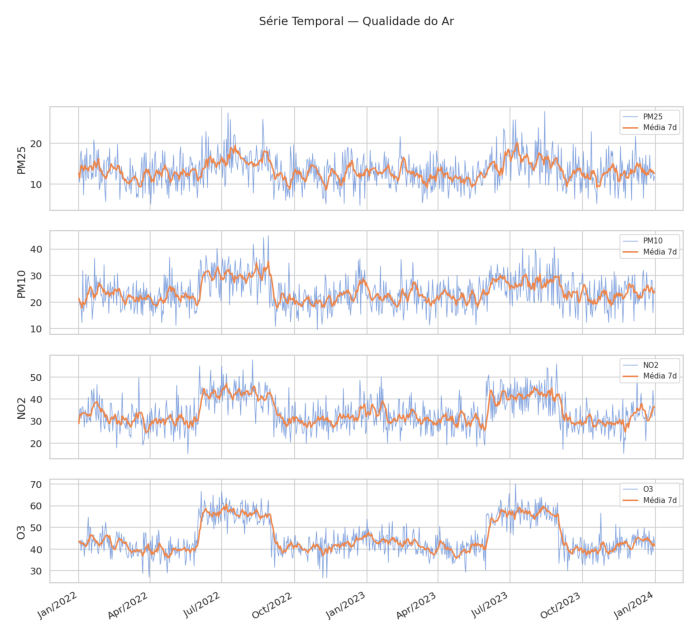

In [20]:
img = PLOTS_DIR / '01_pollution_timeseries.png'
if img.exists():
    plt.figure(figsize=(14, 6))
    plt.imshow(mpimg.imread(img))
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Execute: python -m src.analysis.visualizations')

### 6.2 Série Temporal — Internações Respiratórias

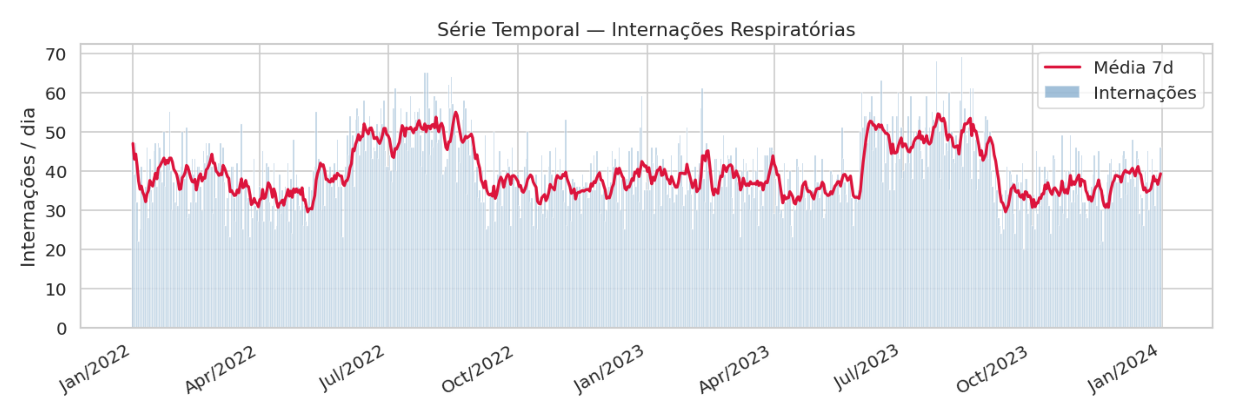

In [21]:
img = PLOTS_DIR / '02_admissions_timeseries.png'
if img.exists():
    plt.figure(figsize=(14, 4))
    plt.imshow(mpimg.imread(img))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### 6.3 Correlação entre Variáveis

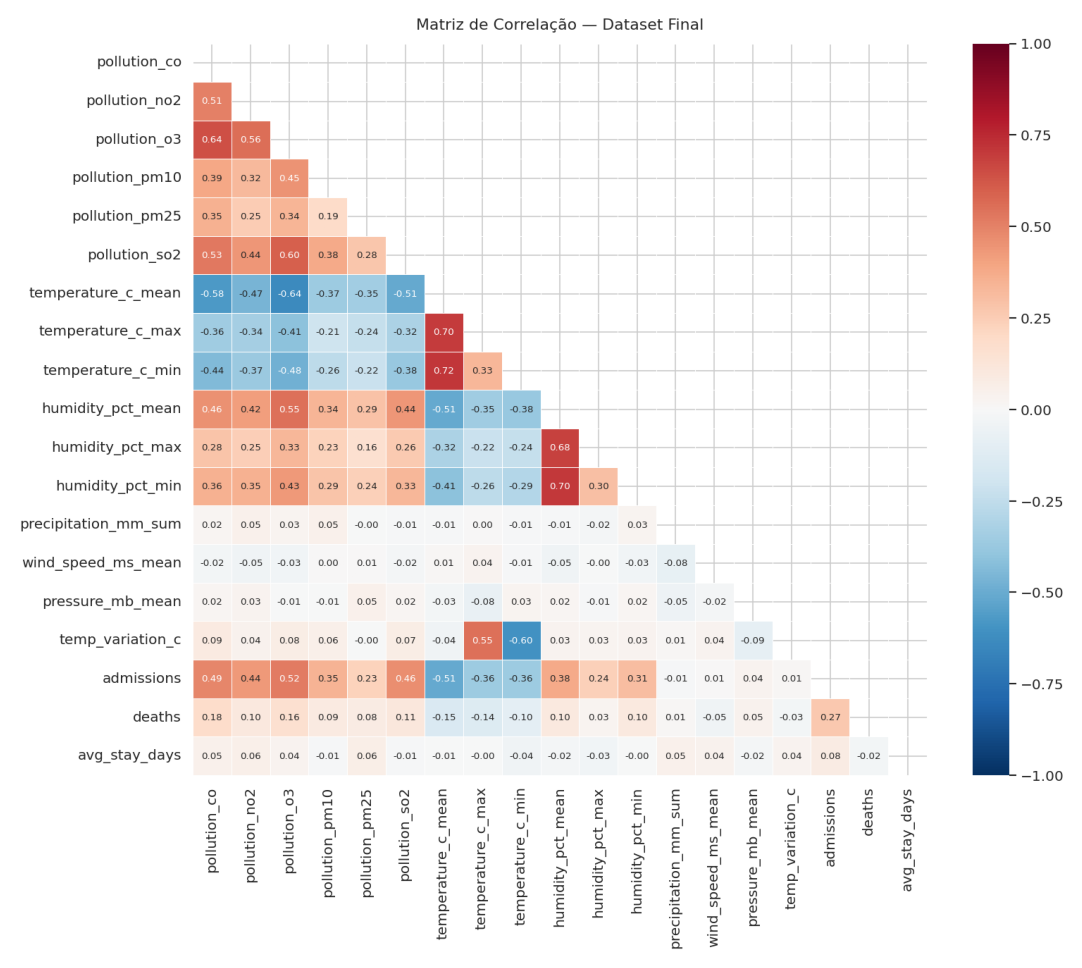

In [22]:
img = PLOTS_DIR / '03_correlation_heatmap.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.imshow(mpimg.imread(img))
    ax.axis('off')
    plt.tight_layout()
    plt.show()

### 6.4 Distribuição dos Poluentes

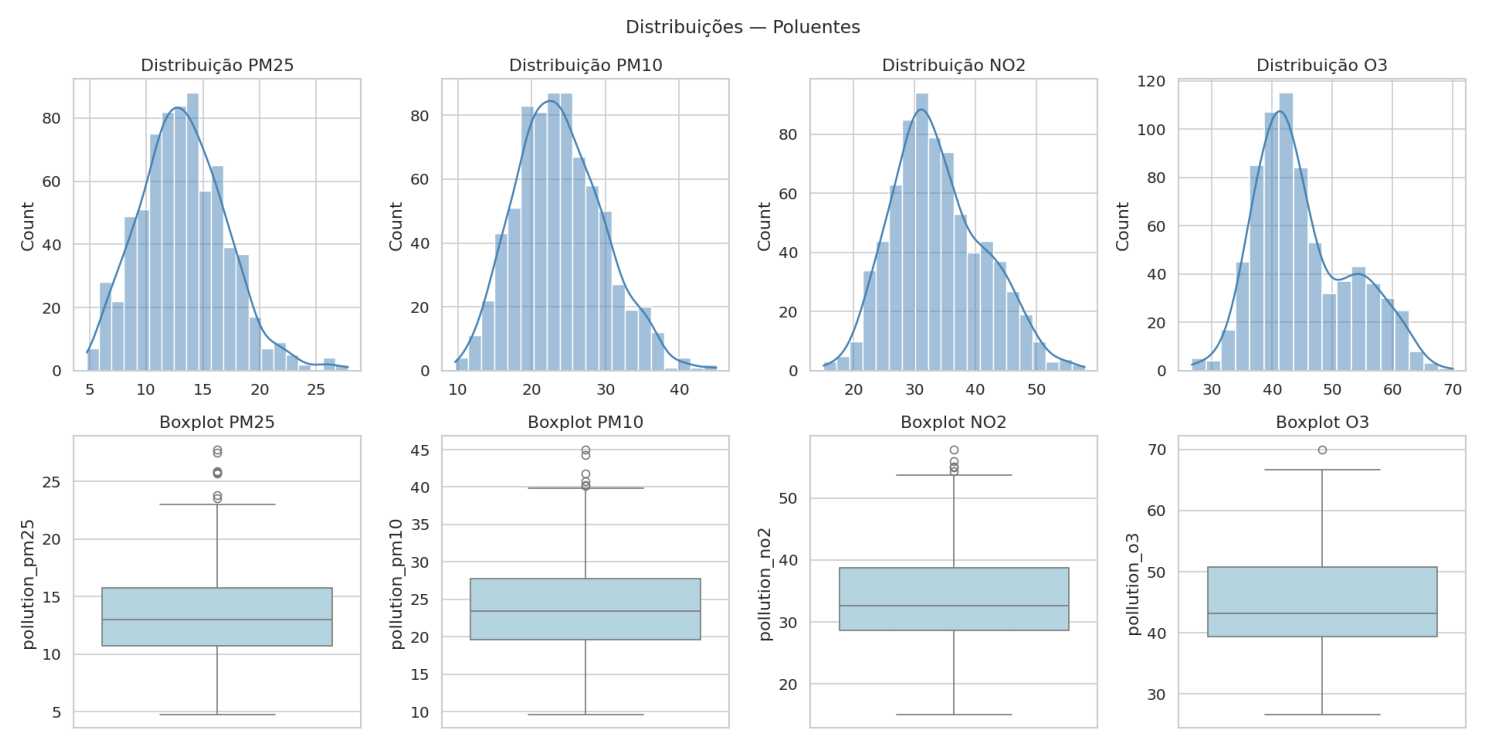

In [23]:
img = PLOTS_DIR / '04_pollution_distributions.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(mpimg.imread(img))
    ax.axis('off')
    plt.tight_layout()
    plt.show()

### 6.5 Poluição × Internações

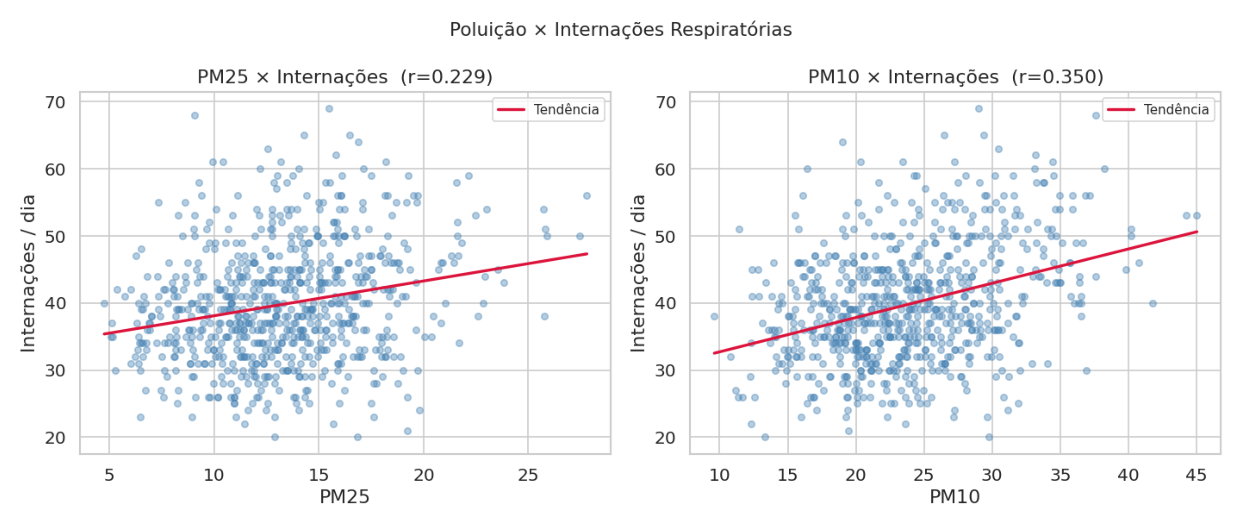

In [24]:
img = PLOTS_DIR / '05_pollution_vs_admissions.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(mpimg.imread(img))
    ax.axis('off')
    plt.tight_layout()
    plt.show()

### 6.6 Tendência Mensal e Sazonalidade

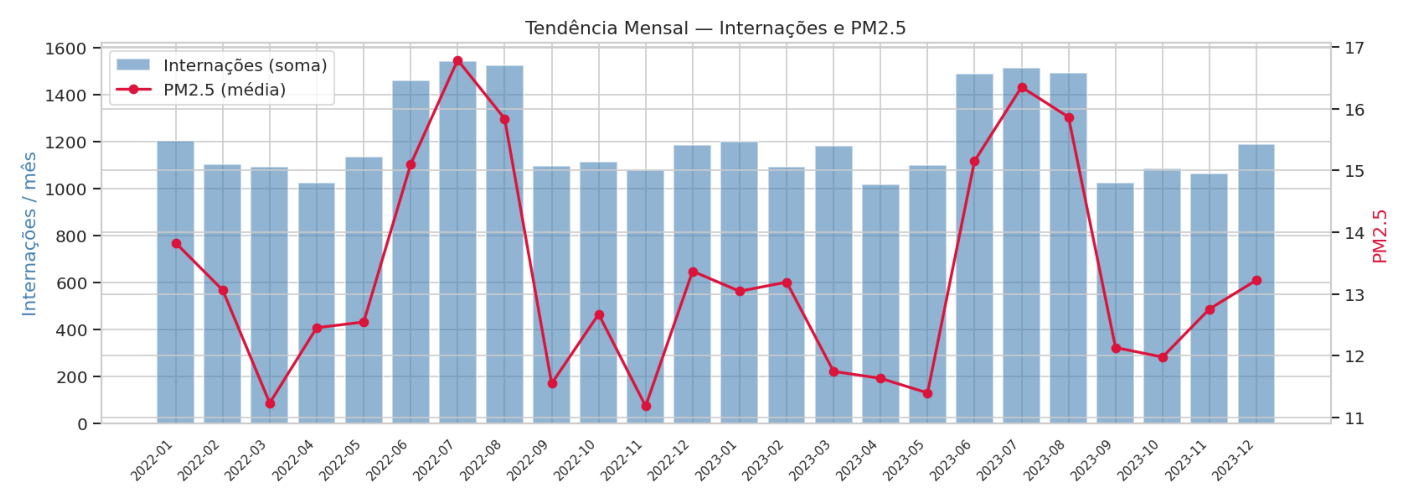

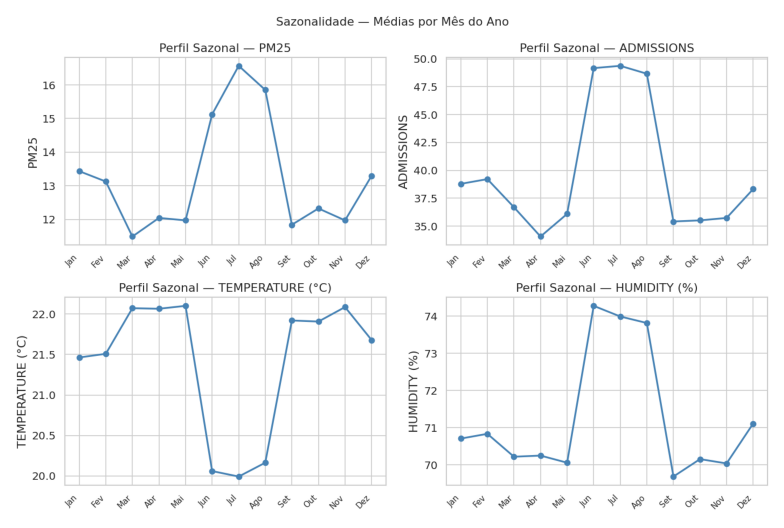

In [25]:
for fname in ['06_monthly_trends.png', '07_seasonal_profile.png']:
    img = PLOTS_DIR / fname
    if img.exists():
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.imshow(mpimg.imread(img))
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## 7. Correlações — Hipóteses do Projeto

In [26]:
hyp_file = ANALYSIS_DIR / 'hypothesis_correlations.csv'
if hyp_file.exists():
    hyp = pd.read_csv(hyp_file).sort_values('abs_r', ascending=False)
    display(hyp[['hypothesis', 'pearson_r', 'strength', 'n_obs']])
else:
    print('Execute: python -m src.analysis.run_analysis')

Execute: python -m src.analysis.run_analysis


## 8. Machine Learning

### 8.1 Regressão Linear — Prever PM2.5

2026-04-30 23:49:04,675 [src.ml.features] INFO: dataset_final carregado: 730 registros.
2026-04-30 23:49:04,677 [src.ml.features] INFO: Regressão — 730 amostras, 5 features.
2026-04-30 23:49:04,678 [src.ml.features] INFO: Split temporal — treino: 584 | teste: 146
2026-04-30 23:49:04,683 [src.ml.models] INFO: Regressão Linear treinada. Coeficientes:
2026-04-30 23:49:04,683 [src.ml.models] INFO:   temperature_c_mean                  -1.1056
2026-04-30 23:49:04,684 [src.ml.models] INFO:   humidity_pct_mean                   +0.5938
2026-04-30 23:49:04,684 [src.ml.models] INFO:   wind_speed_ms_mean                  +0.0556
2026-04-30 23:49:04,684 [src.ml.models] INFO:   temp_variation_c                    -0.0236
2026-04-30 23:49:04,685 [src.ml.models] INFO:   precipitation_mm_sum                -0.0073
2026-04-30 23:49:04,687 [src.ml.evaluate] INFO: Avaliação — Regressão Linear (PM2.5):
2026-04-30 23:49:04,688 [src.ml.evaluate] INFO:   RMSE : 3.6482
2026-04-30 23:49:04,688 [src.ml.evaluat

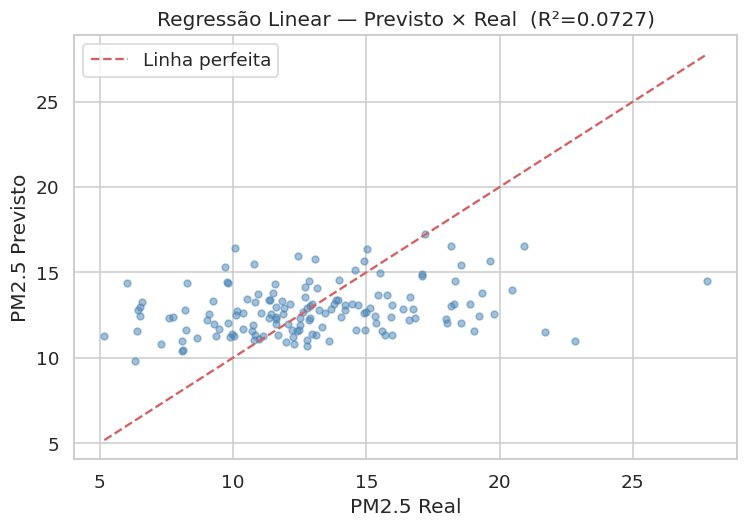

In [27]:
from src.ml.features import load_dataset, prepare_regression, time_based_split
from src.ml.models import train_regression
from src.ml.evaluate import evaluate_regression
import numpy as np

df_ml = load_dataset()
X_reg, y_reg = prepare_regression(df_ml)
X_train_r, X_test_r, y_train_r, y_test_r = time_based_split(X_reg, y_reg)

model_reg = train_regression(X_train_r, y_train_r)
metrics_reg = evaluate_regression(model_reg, X_test_r, y_test_r)

print(f"\nRMSE : {metrics_reg['rmse']}")
print(f"MAE  : {metrics_reg['mae']}")
print(f"R²   : {metrics_reg['r2']}")

# Gráfico previsto × real
y_pred = model_reg.predict(X_test_r)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_r, y_pred, alpha=0.5, s=20, color='steelblue')
lims = [min(y_test_r.min(), y_pred.min()), max(y_test_r.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Linha perfeita')
ax.set_xlabel('PM2.5 Real')
ax.set_ylabel('PM2.5 Previsto')
ax.set_title(f'Regressão Linear — Previsto × Real  (R²={metrics_reg["r2"]})')
ax.legend()
plt.tight_layout()
plt.show()

### 8.2 Árvore de Decisão — Classificar Risco de Internações

2026-04-30 23:49:06,524 [src.ml.features] INFO: Classificação — 730 amostras | threshold internações: 39.0 | positivos: 345 (47.3%)
2026-04-30 23:49:06,525 [src.ml.features] INFO: Split temporal — treino: 584 | teste: 146
2026-04-30 23:49:06,531 [src.ml.models] INFO: Árvore de Decisão treinada. Importância das features:
2026-04-30 23:49:06,531 [src.ml.models] INFO:   temperature_c_mean                  0.6943
2026-04-30 23:49:06,532 [src.ml.models] INFO:   pollution_pm10                      0.1434
2026-04-30 23:49:06,533 [src.ml.models] INFO:   humidity_pct_mean                   0.1164
2026-04-30 23:49:06,534 [src.ml.models] INFO:   pollution_pm25                      0.0446
2026-04-30 23:49:06,534 [src.ml.models] INFO:   temp_variation_c                    0.0014
2026-04-30 23:49:06,547 [src.ml.evaluate] INFO: Avaliação — Árvore de Decisão (risco internações):
2026-04-30 23:49:06,548 [src.ml.evaluate] INFO:   Accuracy  : 0.7055
2026-04-30 23:49:06,549 [src.ml.evaluate] INFO:   Preci

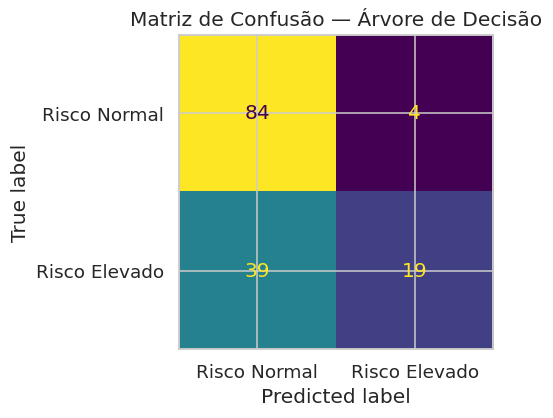

In [28]:
from src.ml.features import prepare_classification
from src.ml.models import train_classification
from src.ml.evaluate import evaluate_classification
from sklearn.metrics import ConfusionMatrixDisplay

X_clf, y_clf = prepare_classification(df_ml)
X_train_c, X_test_c, y_train_c, y_test_c = time_based_split(X_clf, y_clf)

model_clf = train_classification(X_train_c, y_train_c)
metrics_clf = evaluate_classification(model_clf, X_test_c, y_test_c)

print(f"\nAccuracy  : {metrics_clf['accuracy']}")
print(f"Precision : {metrics_clf['precision']}")
print(f"Recall    : {metrics_clf['recall']}")
print(f"F1        : {metrics_clf['f1']}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_c, model_clf.predict(X_test_c),
    display_labels=['Risco Normal', 'Risco Elevado'],
    ax=ax, colorbar=False
)
ax.set_title('Matriz de Confusão — Árvore de Decisão')
plt.tight_layout()
plt.show()

## 9. Insights e Conclusões

### Principais achados

| Hipótese | Resultado |
|---|---|
| PM2.5 correlaciona com internações | Verificar `hypothesis_correlations.csv` |
| Temperatura influencia PM2.5 | Verificar `hypothesis_correlations.csv` |
| Sazonalidade nas internações | Verificar `seasonal_profile.csv` |

### Decisões técnicas documentadas

1. **Split temporal**: usado no lugar de `train_test_split` aleatório para respeitar a ordem cronológica dos dados e evitar *data leakage*.
2. **Target de classificação**: definido como `admissions > mediana` para balancear as classes sem depender de threshold arbitrário.
3. **Agregação estadual**: qualidade do ar e clima foram agregados ao nível de SP antes do join, pois as estações não têm correspondência geográfica direta com os municípios de saúde.
4. **max_depth=5** na Árvore de Decisão: limita overfitting em dataset com ~700 amostras.

### Recomendações para extensão

- Incorporar dados por município para análise geoespacial
- Testar modelos com lag de 3–7 dias entre poluição e internações
- Explorar Random Forest para comparação com a Árvore de Decisão simples
- Adicionar dados socioeconômicos como variável de confundimento